# Predicting Student Health Risk

## Artificial Neural Network Model

This notebook develops an Artificial Neural Network for predicting student health conditions. The ANN is trained using the same training and validation split used by the classical machine learning models. The main evaluation measurement is balanced accuracy.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

print("Libraries imported successfully")
print("TensorFlow version", tf.__version__)

Libraries imported successfully
TensorFlow version 2.21.0


In [84]:
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set successfully")

Random seeds set successfully


In [85]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

data_folder = project_folder / "data" / "kaggle" / "raw"
models_folder = project_folder / "models"
results_folder = project_folder / "outputs" / "results"
figures_folder = project_folder / "outputs" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Project folder")
print(project_folder)

Project folder
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project


In [86]:
train_file = data_folder / "train.csv"
column_file = models_folder / "column_information.joblib"

print("Training file exists", train_file.exists())
print("Column information exists", column_file.exists())

Training file exists True
Column information exists True


In [87]:
train_data = pd.read_csv(train_file)
column_information = joblib.load(column_file)

print("Training dataset loaded successfully")
print("Training dataset shape", train_data.shape)

Training dataset loaded successfully
Training dataset shape (690088, 15)


In [88]:
target_column = column_information["target_column"]
identifier_columns = column_information["identifier_columns"]

X = train_data.drop(columns=[target_column])
y = train_data[target_column]

if len(identifier_columns) > 0:
    X = X.drop(columns=identifier_columns)

print("Input feature shape", X.shape)
print("Target shape", y.shape)

print()

print("Target classes")
print(y.unique())

Input feature shape (690088, 13)
Target shape (690088,)

Target classes
<StringArray>
['unhealthy', 'at-risk', 'fit']
Length: 3, dtype: str


In [89]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    exclude=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Number of numerical columns", len(numerical_columns))
print("Number of categorical columns", len(categorical_columns))

print()

print("Numerical columns")
print(numerical_columns)

print()

print("Categorical columns")
print(categorical_columns)

Number of numerical columns 7
Number of categorical columns 6

Numerical columns
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical columns
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [90]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training input shape", X_train.shape)
print("Validation input shape", X_validation.shape)
print("Training target shape", y_train.shape)
print("Validation target shape", y_validation.shape)

Training input shape (552070, 13)
Validation input shape (138018, 13)
Training target shape (552070,)
Validation target shape (138018,)


In [91]:
print("Training class percentages")
print(
    y_train.value_counts(
        normalize=True
    ).mul(100).round(2)
)

print()

print("Validation class percentages")
print(
    y_validation.value_counts(
        normalize=True
    ).mul(100).round(2)
)

Training class percentages
health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64

Validation class percentages
health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64


In [92]:
numerical_preprocessor = Pipeline(
    steps=[
        (
            "missing_value_handler",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical preprocessing created")

Numerical preprocessing created


In [93]:
categorical_preprocessor = Pipeline(
    steps=[
        (
            "missing_value_handler",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Categorical preprocessing created")

Categorical preprocessing created


In [94]:
ann_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_columns
        )
    ]
)

print("ANN preprocessing pipeline created")

ANN preprocessing pipeline created


In [95]:
X_train_processed = ann_preprocessor.fit_transform(
    X_train
)

X_train_processed = X_train_processed.astype(
    "float32"
)

print("Training data processed successfully")
print("Processed training shape", X_train_processed.shape)

Training data processed successfully
Processed training shape (552070, 25)


In [96]:
X_validation_processed = ann_preprocessor.transform(
    X_validation
)

X_validation_processed = X_validation_processed.astype(
    "float32"
)

print("Validation data processed successfully")
print("Processed validation shape", X_validation_processed.shape)

Validation data processed successfully
Processed validation shape (138018, 25)


In [97]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_validation_encoded = label_encoder.transform(
    y_validation
)

print("Target class encoding")

for class_number, class_name in enumerate(
    label_encoder.classes_
):
    print(class_number, class_name)

Target class encoding
0 at-risk
1 fit
2 unhealthy


In [98]:
class_numbers = np.unique(
    y_train_encoded
)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_numbers,
    y=y_train_encoded
)

class_weight_dictionary = dict(
    zip(
        class_numbers,
        class_weight_values
    )
)

print("Class weights")

for class_number, weight in class_weight_dictionary.items():
    print(class_number, round(weight, 4))

Class weights
0 0.3882
1 5.7793
2 3.985


In [99]:
number_of_inputs = X_train_processed.shape[1]
number_of_classes = len(label_encoder.classes_)

print("Number of ANN inputs", number_of_inputs)
print("Number of output classes", number_of_classes)

Number of ANN inputs 25
Number of output classes 3


In [100]:
ann_model = tf.keras.Sequential(
    [
        tf.keras.Input(
            shape=(number_of_inputs,)
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dropout(
            0.30
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dropout(
            0.20
        ),

        tf.keras.layers.Dense(
            number_of_classes,
            activation="softmax"
        )
    ]
)

print("ANN model created successfully")

ANN model created successfully


In [101]:
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843 (15.01 KB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ANN model compiled successfully")

ANN model compiled successfully


In [103]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Early Stopping created successfully")

Early Stopping created successfully


In [104]:
ann_history = ann_model.fit(
    X_train_processed,
    y_train_encoded,
    validation_data=(
        X_validation_processed,
        y_validation_encoded
    ),
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dictionary,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8095 - loss: 0.3855 - val_accuracy: 0.8595 - val_loss: 0.3704
Epoch 2/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8629 - loss: 0.3143 - val_accuracy: 0.8707 - val_loss: 0.3338
Epoch 3/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8712 - loss: 0.2980 - val_accuracy: 0.8813 - val_loss: 0.3255
Epoch 4/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8722 - loss: 0.2883 - val_accuracy: 0.8773 - val_loss: 0.3176
Epoch 5/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8728 - loss: 0.2812 - val_accuracy: 0.8813 - val_loss: 0.3073
Epoch 6/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8727 - loss: 0.2762 - val_accuracy: 0.8763 - val_loss: 0.3014
Epoch 7/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8727 - loss: 0.2717 - val_accuracy: 0.8780 - val_loss: 0.2974
Epoch 8/30
2157/2157 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8759 - loss: 0.2696 - 

In [105]:
completed_epochs = len(
    ann_history.history["loss"]
)

print("Completed training epochs")
print(completed_epochs)

Completed training epochs
28


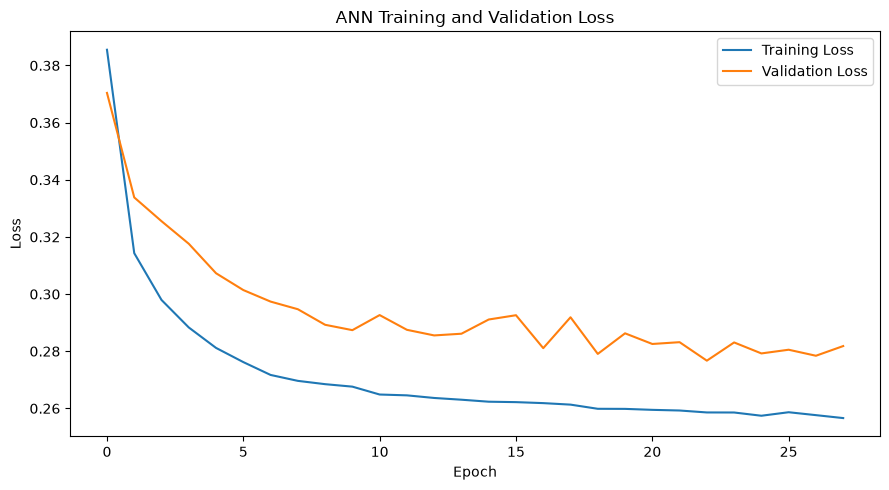

In [106]:
plt.figure(figsize=(9, 5))

plt.plot(
    ann_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    ann_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_figure = figures_folder / "ann_training_loss.png"

plt.savefig(loss_figure)
plt.show()

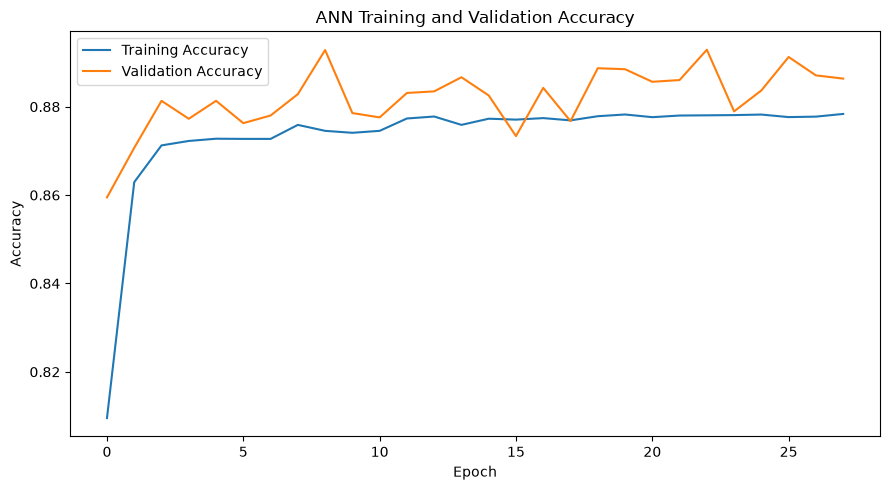

In [107]:
plt.figure(figsize=(9, 5))

plt.plot(
    ann_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    ann_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

accuracy_figure = figures_folder / "ann_training_accuracy.png"

plt.savefig(accuracy_figure)
plt.show()

In [108]:
validation_probabilities = ann_model.predict(
    X_validation_processed,
    batch_size=1024
)

print("Probability prediction shape")
print(validation_probabilities.shape)

print()

print("First prediction probabilities")
print(validation_probabilities[0])

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
Probability prediction shape
(138018, 3)

First prediction probabilities
[0.94166625 0.00192917 0.05640448]


In [109]:
validation_encoded_predictions = np.argmax(
    validation_probabilities,
    axis=1
)

validation_predictions = label_encoder.inverse_transform(
    validation_encoded_predictions
)

print("First ten predicted classes")
print(validation_predictions[:10])

First ten predicted classes
['at-risk' 'at-risk' 'at-risk' 'at-risk' 'at-risk' 'at-risk' 'at-risk'
 'at-risk' 'at-risk' 'at-risk']


In [110]:
training_probabilities = ann_model.predict(
    X_train_processed,
    batch_size=1024
)

training_encoded_predictions = np.argmax(
    training_probabilities,
    axis=1
)

training_predictions = label_encoder.inverse_transform(
    training_encoded_predictions
)

print("Training predictions completed")

540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step
Training predictions completed


In [111]:
ann_training_balanced_accuracy = balanced_accuracy_score(
    y_train,
    training_predictions
)

ann_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    validation_predictions
)

ann_normal_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

ann_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro"
)

print("Training balanced accuracy")
print(round(ann_training_balanced_accuracy, 4))

print()

print("Validation balanced accuracy")
print(round(ann_validation_balanced_accuracy, 4))

print()

print("Normal accuracy")
print(round(ann_normal_accuracy, 4))

print()

print("Macro F1 score")
print(round(ann_macro_f1, 4))

Training balanced accuracy
0.9043

Validation balanced accuracy
0.9027

Normal accuracy
0.8929

Macro F1 score
0.7783


In [112]:
print(
    classification_report(
        y_validation,
        validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.98      0.89      0.93    118512
         fit       0.52      0.91      0.67      7961
   unhealthy       0.62      0.90      0.73     11545

    accuracy                           0.89    138018
   macro avg       0.71      0.90      0.78    138018
weighted avg       0.93      0.89      0.90    138018



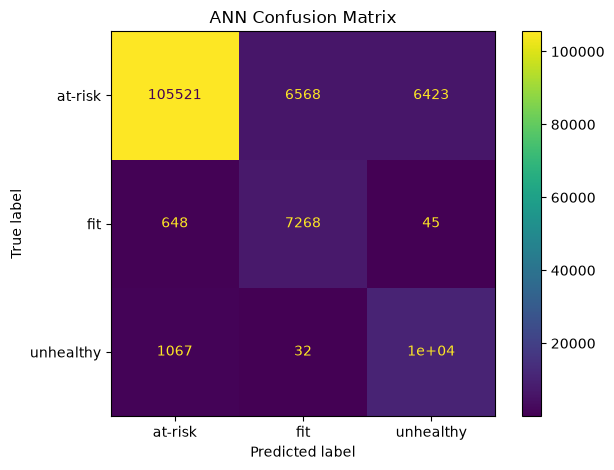

In [113]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions
)

plt.title("ANN Confusion Matrix")
plt.tight_layout()

confusion_figure = figures_folder / "ann_confusion_matrix.png"

plt.savefig(confusion_figure)
plt.show()

In [114]:
ann_result = pd.DataFrame(
    {
        "Model": [
            "Artificial Neural Network"
        ],
        "Training Balanced Accuracy": [
            ann_training_balanced_accuracy
        ],
        "Validation Balanced Accuracy": [
            ann_validation_balanced_accuracy
        ],
        "Normal Accuracy": [
            ann_normal_accuracy
        ],
        "Macro F1 Score": [
            ann_macro_f1
        ]
    }
)

ann_result = ann_result.round(4)

ann_result

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Artificial Neural Network,0.9043,0.9027,0.8929,0.7783


In [115]:
tree_results_file = (
    results_folder
    / "tree_based_model_comparison.csv"
)

if tree_results_file.exists():
    tree_results = pd.read_csv(
        tree_results_file
    )

    ann_tree_comparison = pd.concat(
        [
            tree_results,
            ann_result
        ],
        ignore_index=True
    )
else:
    ann_tree_comparison = ann_result.copy()

ann_tree_comparison = ann_tree_comparison.sort_values(
    by="Validation Balanced Accuracy",
    ascending=False
)

ann_tree_comparison

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,XGBoost,0.9113,0.9097,0.8730,0.7541
1,Random Forest,0.9175,0.9054,0.8927,0.7787
3,Artificial Neural Network,0.9043,0.9027,0.8929,0.7783
2,Decision Tree,0.9026,0.9020,0.8558,0.7308


In [116]:
best_model_name = ann_tree_comparison.iloc[0][
    "Model"
]

best_model_score = ann_tree_comparison.iloc[0][
    "Validation Balanced Accuracy"
]

print("Best model so far")
print(best_model_name)

print()

print("Best validation balanced accuracy")
print(best_model_score)

Best model so far
XGBoost

Best validation balanced accuracy
0.9097


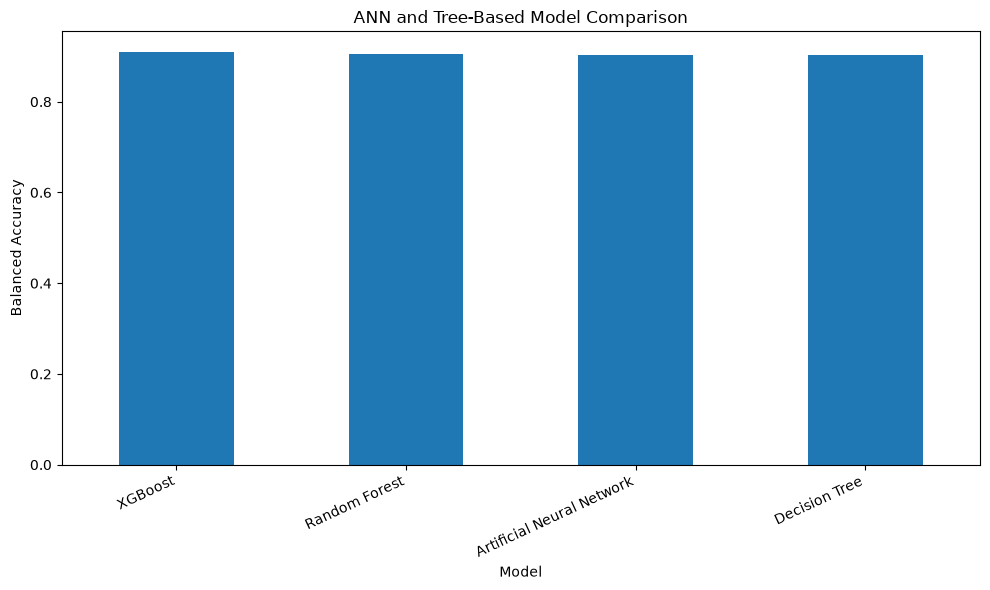

In [117]:
ann_tree_comparison.plot(
    x="Model",
    y="Validation Balanced Accuracy",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("ANN and Tree-Based Model Comparison")
plt.xlabel("Model")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

comparison_figure = figures_folder / "ann_tree_model_comparison.png"

plt.savefig(comparison_figure)
plt.show()

In [118]:
ann_model_file = models_folder / "ann_model.keras"

ann_model.save(
    ann_model_file
)

print("ANN model saved successfully")
print(ann_model_file)

ANN model saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\ann_model.keras


In [119]:
ann_preprocessor_file = (
    models_folder
    / "ann_preprocessing_pipeline.joblib"
)

joblib.dump(
    ann_preprocessor,
    ann_preprocessor_file
)

print("ANN preprocessor saved successfully")
print(ann_preprocessor_file)

ANN preprocessor saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\ann_preprocessing_pipeline.joblib


In [120]:
ann_label_encoder_file = (
    models_folder
    / "ann_label_encoder.joblib"
)

joblib.dump(
    label_encoder,
    ann_label_encoder_file
)

print("ANN label encoder saved successfully")
print(ann_label_encoder_file)

ANN label encoder saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\ann_label_encoder.joblib


In [121]:
history_data = pd.DataFrame(
    ann_history.history
)

history_file = (
    results_folder
    / "ann_training_history.csv"
)

history_data.to_csv(
    history_file,
    index=False
)

print("ANN training history saved successfully")

ANN training history saved successfully


In [122]:
comparison_file = (
    results_folder
    / "ann_tree_model_comparison.csv"
)

ann_tree_comparison.to_csv(
    comparison_file,
    index=False
)

print("Model comparison saved successfully")
print(comparison_file)

Model comparison saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\outputs\results\ann_tree_model_comparison.csv


In [123]:
print("ANN model saved")
print(ann_model_file.exists())

print()

print("ANN preprocessor saved")
print(ann_preprocessor_file.exists())

print()

print("ANN label encoder saved")
print(ann_label_encoder_file.exists())

print()

print("ANN training history saved")
print(history_file.exists())

print()

print("ANN comparison saved")
print(comparison_file.exists())

ANN model saved
True

ANN preprocessor saved
True

ANN label encoder saved
True

ANN training history saved
True

ANN comparison saved
True


## ANN model findings

The ANN contained two hidden layers with 64 and 32 neurons.

ReLU was used in the hidden layers and Softmax was used in the output layer.

Dropout and class weights were used to reduce overfitting and handle class imbalance.

The model completed 28 training epochs.

The ANN training balanced accuracy was 0.9043.

The ANN validation balanced accuracy was 0.9027.

The normal accuracy was 0.8929 and the Macro F1 score was 0.7783.

The generalisation gap was only 0.0016, showing that the ANN performed consistently without clear overfitting.

The ANN performed competitively but did not exceed XGBoost on balanced accuracy.

The results suggest that deep learning is suitable for this dataset, but it was not the strongest or simplest approach.